# filter / where — try it live

Runnable companion to the note: **[filter / where](https://ravi-writes.pages.dev/notes/abinitio-to-pyspark/core-operations/filter)**.

`filter` (alias `where`) keeps only the rows where a condition is **true** — Ab Initio's **Filter By Expression**. Run the cells top to bottom.

## The data & the requirement

Six customers — each row is `id`, `name`, `signup_date`, `balance`.

**Requirement:** keep only the customers with a **positive balance** *and* a **name on file** — drop everyone else.

In [ ]:
data = [
    (1, "Asha",  "2024-03-01", 120.0),
    (2, "Ben",   "2023-11-05",   0.0),
    (3, None,    "2024-06-20",  45.0),   # name is null
    (4, "Chen",  "2024-01-15", 300.0),
    (5, "Diego", "2023-09-30", None),    # balance is null
    (6, "Esha",  "2024-05-02", -20.0),
]

## The Ab Initio solution

*Create Data → Filter By Expression → Trash.* The **FBE** splits on the condition: the **`select`** port carries the rows that matched (kept), the **`deselect`** port the rows that *did not match*. (Not the `reject` port — that's for records that *errored*; a `deselect` row is valid, it just tested false.)

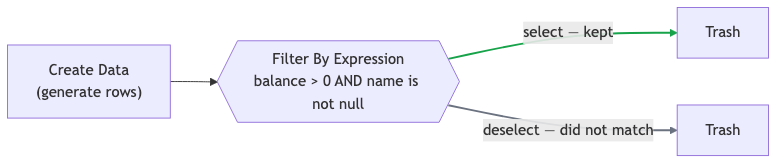

## The Spark solution — step by step

In [ ]:
# 1. Install PySpark (one-time, in Colab's runtime)
!pip install -q pyspark

In [ ]:
# 2. Imports & SparkSession — the builder object (see the Python-for-Spark notes)
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.sql.types import (
    StructType, StructField, IntegerType, StringType, DoubleType,
)

spark = SparkSession.builder.appName("filter-demo").getOrCreate()

In [ ]:
# 3. Load the rows into a DataFrame — explicit schema so the types are exact (the DML)
schema = StructType([
    StructField("id",          IntegerType(), nullable=False),
    StructField("name",        StringType(),  nullable=True),
    StructField("signup_date", StringType(),  nullable=True),
    StructField("balance",     DoubleType(),  nullable=True),
])

df = spark.createDataFrame(data, schema)
df.show()

In [ ]:
# 4. Express the condition — & binds tighter than >, so parenthesize each side
keep = (col("balance") > 0) & col("name").isNotNull()

# In Ab Initio Graph - We generally handle null explicitly so condition would be like below
# (!isNull(balance) AND balance > 0) AND (!isNull(name))

In [ ]:
# 5. Apply the filter — the FBE 'select' port
kept = df.filter(keep)
kept.show()

## Your turn

Try these yourself:

1. **Capture what didn't match** — the `deselect` port: filter with the negated condition `~(...)`.
2. **SQL style** — rewrite as `df.where("balance > 0 AND name IS NOT NULL")` and confirm it matches.
3. **Watch nulls disappear** — run `df.filter(col("balance") > 100)`; Diego (null balance) drops even though you never filtered on his name. Why?